# Insurance Cost Prediction

## Problem Statement
There's a lot of risk within the realm of insurance for both the insurer aswell as the customer.
Our goal is to predict individual medical insurance costs based on personal attributes (age, BMI, smoking status, etc.) to help insurers assess risk and set appropriate costs.

## Methodology
1. **Data Exploration** - Understand distributions and relationships
2. **Data Preprocessing** - Handle missing values, encode categorical variables
3. **Feature Analysis** - Identify key predictors.


## Data Dictionary

| Variable | Data Type | Description |
|----------|-----------|-------------|
| **age** | Integer | Age of the primary beneficiary (in years) |
| **sex** | Categorical | Gender of the insurance contractor (male, female) |
| **bmi** | Float | Body Mass Index - a measure of body fat based on height and weight (kg/m²). Ideally 18.5 to 24.9 |
| **children** | Integer | Number of children/dependents covered by the insurance plan |
| **smoker** | Categorical | Whether the beneficiary is a smoker (yes, no) |
| **region** | Categorical | The beneficiary's residential area in the US (northeast, northwest, southeast, southwest) |
| **charges** | Float | Individual medical costs billed by health insurance (target variable) |

## Data Import & Cleaning

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('insurance.csv')


In [2]:
# Check data info and missing values
print(f"Shape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nData types:\n{df.dtypes}")

Shape: (1338, 7)

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Data types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [3]:
# Check for duplicates and basic stats
print(f"Duplicates: {df.duplicated().sum()}")
df.describe()

Duplicates: 1


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [4]:
# Display the duplicate row(s)
df[df.duplicated(keep=False)]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


## Final Predictor and Target Value(s):
- We want to predict the charges of insurance, based on the personal characteristics of the customer.
- All of our values are going to be pretty helpfull (we dont have many, only 7 total)
- Our predictor values are ['age', 'sex', 'bmi', 'children', 'smoker', 'region'],
- And our Target value is the charges.

## Things to consider moving forward:
- Plan moving forward is to do feature engineering and PCA (standardize).
- Binning BMI into categories
- Age groups
- Smoke x bmi may have high correlation
- Outliers

# Deliverable 2

## Correlation Analysis

We examine relationships between variables using:
1. **Correlation heatmap** of numeric features
2. **Encoded correlation heatmap** including categorical variables (label-encoded)
3. **Pairplot** to visualize feature-target relationships

This helps identify multicollinear (highly correlated) predictor pairs that could destabilize regression models.

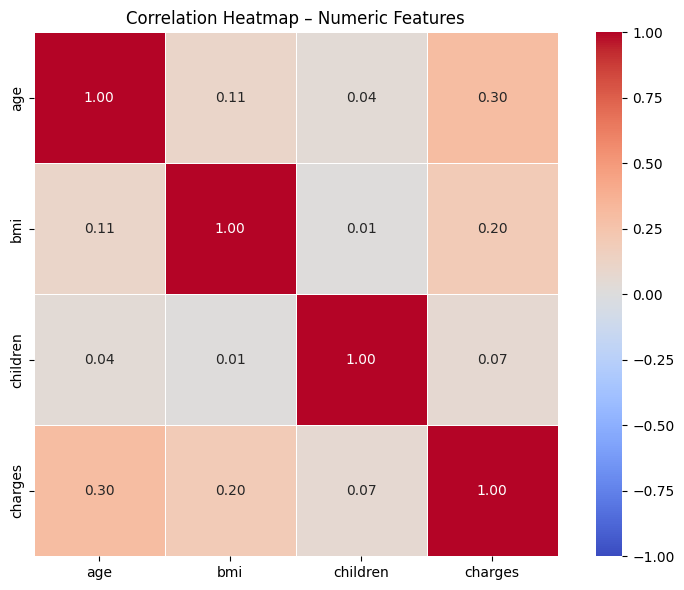

Numeric feature correlations with charges:
age         0.299008
bmi         0.198341
children    0.067998


In [3]:
# Correlation heatmap of numeric features
numeric_cols = df.select_dtypes(include=[np.number])
corr_numeric = numeric_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_numeric, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, vmin=-1, vmax=1)
plt.title('Correlation Heatmap – Numeric Features')
plt.tight_layout()
plt.show()

print("Numeric feature correlations with charges:")
print(corr_numeric['charges'].drop('charges').sort_values(ascending=False).to_string())

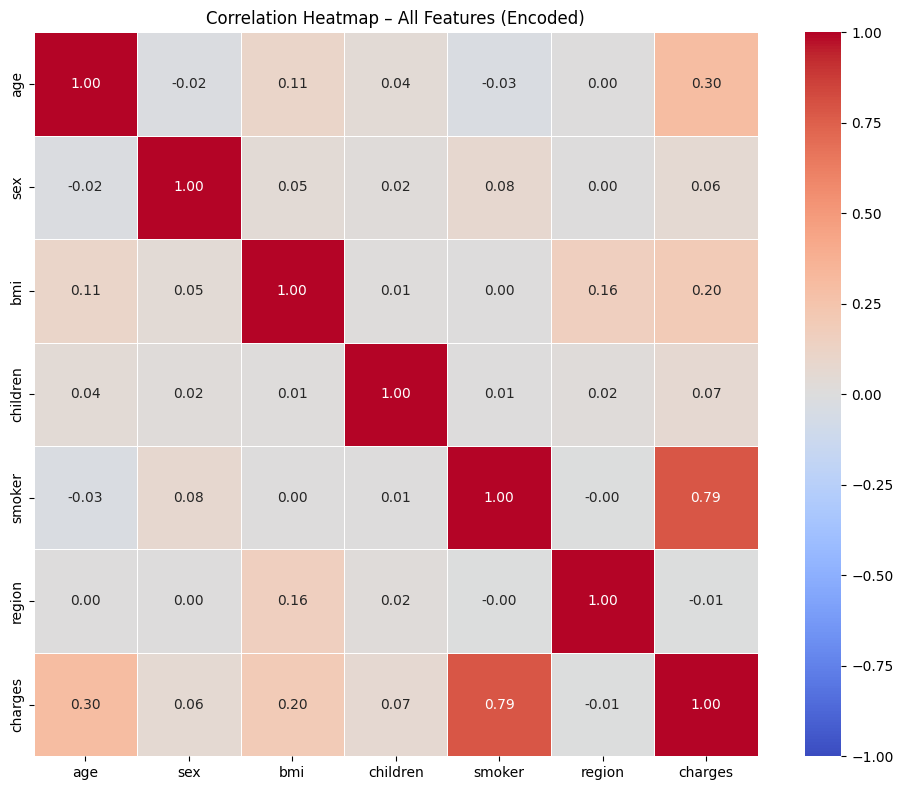


Full feature correlations with charges (sorted):
smoker      0.787251
age         0.299008
bmi         0.198341
children    0.067998
sex         0.057292
region     -0.006208


In [4]:
# Encode categorical variables for full correlation analysis
df_encoded = df.copy()
df_encoded['sex'] = df_encoded['sex'].map({'male': 1, 'female': 0})
df_encoded['smoker'] = df_encoded['smoker'].map({'yes': 1, 'no': 0})
df_encoded['region'] = df_encoded['region'].astype('category').cat.codes

corr_full = df_encoded.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_full, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, vmin=-1, vmax=1)
plt.title('Correlation Heatmap – All Features (Encoded)')
plt.tight_layout()
plt.show()

print("\nFull feature correlations with charges (sorted):")
print(corr_full['charges'].drop('charges').sort_values(ascending=False).to_string())

Checking for multicollinearity among predictors (|r| > 0.7):

  ✓ No predictor pairs exceed |r| > 0.7
    No variables need to be removed due to multicollinearity.


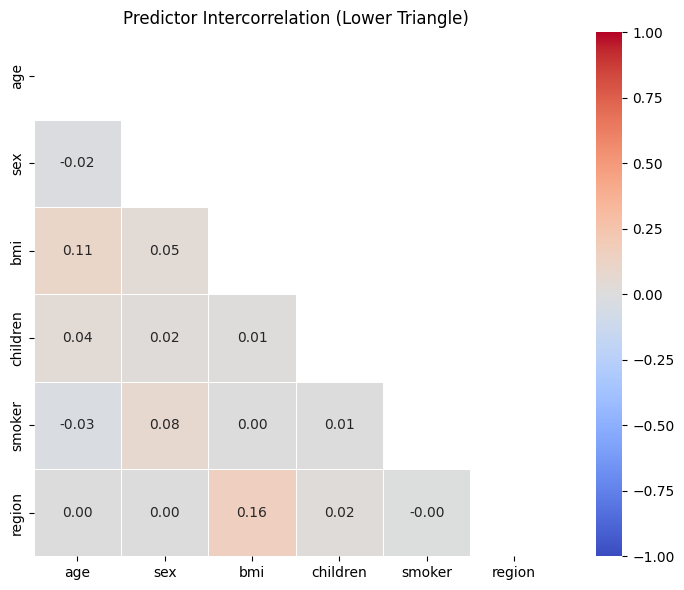

In [5]:
# Check for multicollinearity: identify predictor pairs with |r| > 0.7
predictors = ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
corr_predictors = df_encoded[predictors].corr()

print("Checking for multicollinearity among predictors (|r| > 0.7):\n")
high_corr_pairs = []
for i in range(len(predictors)):
    for j in range(i + 1, len(predictors)):
        r = corr_predictors.iloc[i, j]
        if abs(r) > 0.7:
            high_corr_pairs.append((predictors[i], predictors[j], r))

if high_corr_pairs:
    for feat1, feat2, r in high_corr_pairs:
        print(f"  ⚠ {feat1} & {feat2}: r = {r:.3f}")
else:
    print("  ✓ No predictor pairs exceed |r| > 0.7")
    print("    No variables need to be removed due to multicollinearity.")

# Show predictor-only correlation heatmap
plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_predictors, dtype=bool))
sns.heatmap(corr_predictors, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, linewidths=0.5, square=True, vmin=-1, vmax=1)
plt.title('Predictor Intercorrelation (Lower Triangle)')
plt.tight_layout()
plt.show()

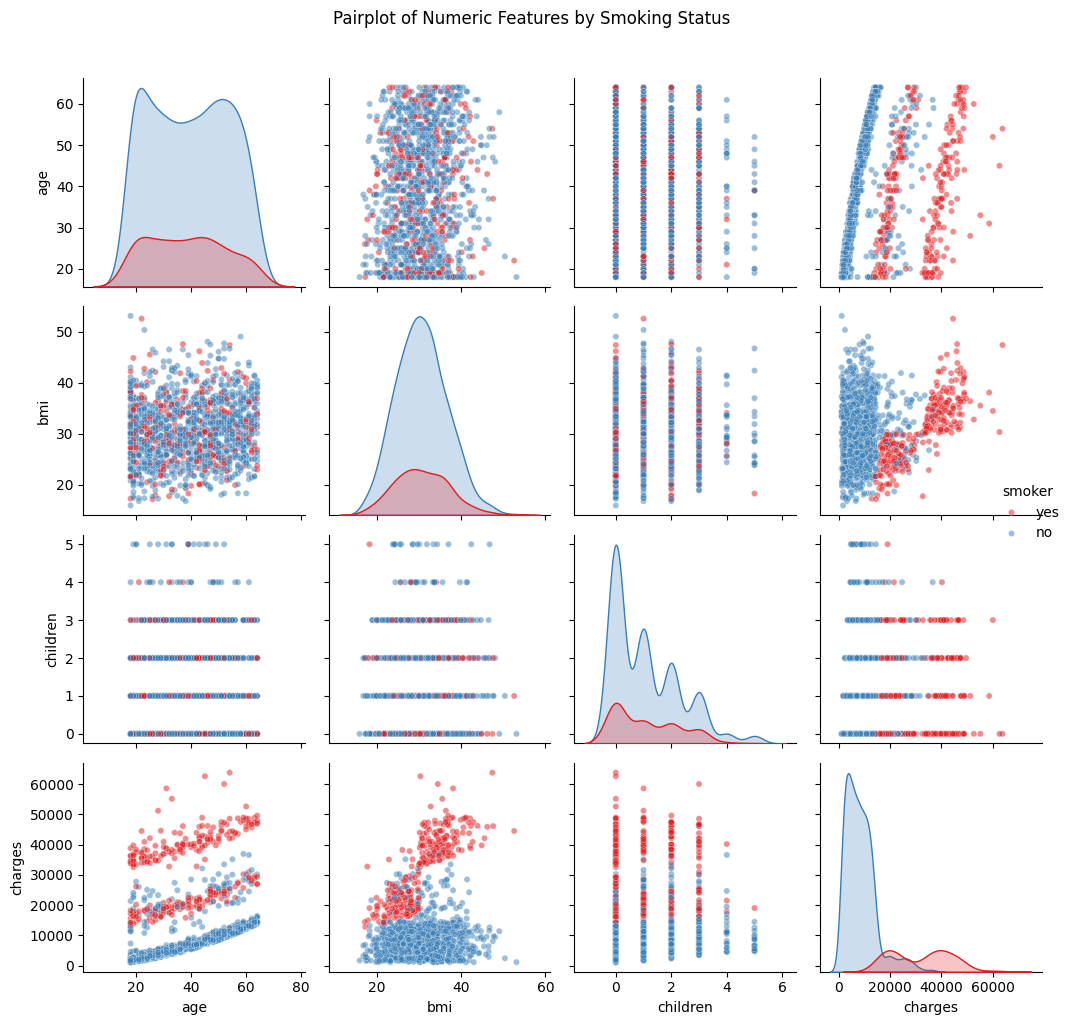

In [6]:
# Pairplot colored by smoker status to visualize feature-target relationships
sns.pairplot(df, hue='smoker', vars=['age', 'bmi', 'children', 'charges'],
             palette='Set1', diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20})
plt.suptitle('Pairplot of Numeric Features by Smoking Status', y=1.02)
plt.tight_layout()
plt.show()

### Correlation Analysis – Key Findings

**Strongest predictors of `charges`:**
- **smoker** has the highest correlation with charges (~0.79), confirming smoking status is the dominant cost driver.
- **age** shows a moderate positive correlation (~0.30), as older individuals tend to incur higher medical costs
- **bmi** has a weak-to-moderate positive correlation (~0.20)

**Multicollinearity assessment:**
- No pair of predictor variables exceeds |r| > 0.7, meaning **no variables were removed** due to multicollinearity
- All six predictors (age, sex, bmi, children, smoker, region) are retained for modeling since they carry largely independent information

**Notable interaction (from pairplot):**
- The pairplot reveals that smokers with higher BMI form a distinct cluster, suggesting a **smoker × BMI interaction** may be a valuable engineered feature